In [9]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected:", gpus)
    
    # Optional: prevent TensorFlow from allocating all VRAM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

else:
    print("No GPU detected. Running on CPU.")

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [10]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [14]:
data_dir = "/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset"
img_height = 224
img_width = 224
batch_size = 64
seed = 123

train_ds  = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,# trainign percentatge
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)
val_ds  = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,     # same split
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)
class_names = train_ds.class_names
print(class_names)


Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.
['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [19]:
num_classes=len(class_names)

model = keras.Sequential([
    layers.Input(batch_shape=(batch_size, img_height, img_width, 1)),
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(256),
    layers.Dense(128),
    layers.Dense(num_classes)
])

In [20]:
model.compile(
    optimizer='SGD',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [21]:
model.summary()
epochs=10
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (64, 224, 224, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (64, 50176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (64, 256)              │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (64, 128)              │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (64, 5)                │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,878,853 (49.13 MB)

 Trainable params: 12,878,853 (49.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10


I0000 00:00:1773534309.937115     154 service.cc:152] XLA service 0x7e8e08009450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773534309.937156     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773534309.937160     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773534310.279232     154 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/938 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.2392 - loss: 10.7866

I0000 00:00:1773534311.692727     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


938/938 ━━━━━━━━━━━━━━━━━━━━ 158s 166ms/step - accuracy: 0.8698 - loss: 1.2306 - val_accuracy: 0.9649 - val_loss: 0.1068
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.9592 - loss: 0.1161 - val_accuracy: 0.9643 - val_loss: 0.1050
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9635 - loss: 0.1063 - val_accuracy: 0.9638 - val_loss: 0.1056
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9654 - loss: 0.1021 - val_accuracy: 0.9685 - val_loss: 0.0928
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9644 - loss: 0.1025 - val_accuracy: 0.9526 - val_loss: 0.1411
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9675 - loss: 0.0958 - val_accuracy: 0.9669 - val_loss: 0.0964
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 39ms/step - accuracy: 0.9687 - loss: 0.0929 - val_accuracy: 0.9646 - val_loss: 0.1020
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9694 - loss: 0.0914 - val_accur

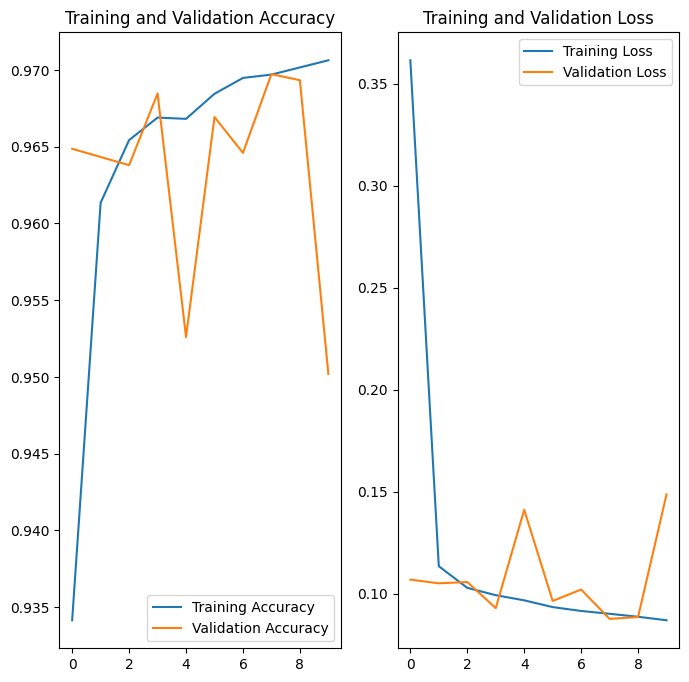

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [25]:
test_loss, test_acc = model.evaluate(val_ds)
print(test_acc)

235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9509 - loss: 0.1506
0.9502000212669373
